 ## generator cost and carbon notebook - export excel: for each gen - bus, region, capacity, cost, carbon. 


In [2]:
import pandas as pd
import numpy as np

Units = pd.read_csv("../cost_and_carbon/LCOE_cal/data/Units.csv")
Units = Units[Units["Status"]=='operating']
cond_oil = Units["Technology"].eq("oil")
Units.loc[cond_oil, "type"] = "oil"


Units = Units[Units["type"]!="cascade"]

BASE_MAP = {
    "offwind": "offshore_wind",
    "onwind":  "onshore_wind",
    "gas":     "ccgt",
    "biomass": "biomass",
    "fossil":   "ccgt",
    "oil":     "oil",
    "nuclear": "nuclear",
}

SOLAR_BUCKETS = [
    (0.0,     0.004,  "PV(<4kW)"),     # <50 kW
    (0.004,    0.01,   "PV(4-10kW)"),     # 50 kW–1 MW
    (0.01,     0.05,   "PV(10-50kW)"),    # 1–5 MW
    (0.05,     np.inf,"PV(50kW+)"),   # ≥5 MW
]

ONWIND_BUCKETS = [
    (0.0,     1.0,  "onshore_wind(<1MW))"),     # <1 MW
    (1.0,     3.0,   "onshore_wind(1-3MW)"),     # 1 MW – 3 MW
    (3.0,    np.inf,   "onshore_wind(>3MW)"),    # >3 MW
]

def pick_solar_tech(cap_mw: float) -> str:
    for lo, hi, name in SOLAR_BUCKETS:
        if lo <= cap_mw < hi:
            return name
    return SOLAR_BUCKETS[-1][2]

def pick_wind_tech(cap_mw: float) -> str:
    for lo, hi, name in ONWIND_BUCKETS:
        if lo <= cap_mw < hi:
            return name
    return ONWIND_BUCKETS[-1][2]

def normalize_type(t: str, cap_mw: float) -> str:
    t_norm = str(t).strip().lower()
    if "solar" in t_norm or t_norm == "pv":
        return pick_solar_tech(cap_mw)
    if "onwind" in t_norm or t_norm == "onshore_wind":
        return pick_wind_tech(cap_mw)
    return BASE_MAP.get(t_norm, t_norm)

Units["tech"] = Units.apply(lambda r: normalize_type(r["type"], float(r["capacity"])), axis=1)
# Units = Units[["name", "tech", "capacity"]]
Units.rename(columns={"name": "id", "capacity": "capacity_mw", "Technology": "Type"}, inplace=True)

lcoe_by_unit = pd.read_csv('../cost_and_carbon/LCOE_cal/lcoe_by_unit.csv')
lca_by_unit = pd.read_csv('../cost_and_carbon/LCA_cal/lca_by_unit.csv')

Units['Cost'] = Units['id'].map(lcoe_by_unit.set_index('id')['lcoe_total'])
Units['Carbon'] = Units['id'].map(lca_by_unit.set_index('id')['lca'])

Units

,Unnamed: 0,UnitID,id,type,Bus name,x,y,capacity_mw,Type,Cost,Start Year,Retired Year,Status,tech,Carbon
0,0,1,DRAXD-2,biomass,way/160580052-400,-0.996389,53.735800,2580.0,biomass,230.224337,1975.0,NaN,operating,biomass,53.1
10,10,11,biomass_27,biomass,way/91010711-400,0.492400,51.293100,43.0,biomass,230.601565,2008.0,NaN,operating,biomass,53.1
11,11,12,biomass_120,biomass,way/292471784-400,-2.668700,51.532900,34.0,biomass,230.703112,2021.0,NaN,operating,biomass,53.1
12,12,13,biomass_181,biomass,way/101312018-275,-1.400700,53.420400,30.0,biomass,230.767801,1921.0,NaN,operating,biomass,53.1
13,13,14,biomass_199,biomass,GB32-400,-0.509200,53.542300,40.0,biomass,230.630336,2016.0,NaN,operating,biomass,53.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4413,4414,4415,gas_9472,gas,way/26678829-400,-3.531310,50.712540,21.0,gas,93.549502,not found,NaN,operating,ccgt,384.0
4414,4415,4416,gas_9473,gas,relation/13110369-400,-0.811836,53.362719,450.0,gas,84.103442,2013,NaN,operating,ccgt,384.0
4415,4416,4417,gas_9474,gas,relation/13110369-400,-0.811836,53.362719,460.0,gas,84.093390,2013,NaN,operating,ccgt,384.0
4416,4417,4418,gas_9475,gas,relation/13110369-400,-0.811836,53.362719,450.0,gas,84.103442,2013,NaN,operating,ccgt,384.0


## Reindex UnitID

In [3]:
Units = Units[['UnitID', "Bus name", "x", 'y', "capacity_mw", "Cost", "Carbon", 'Type']]
Units = Units.sort_values("UnitID").reset_index(drop=True)
Units['UnitID'] = Units.index + 1

## Map Units to different regions

In [ ]:
from shapely.geometry import Point
import geopandas as gpd

# Load the regions GeoDataFrame
regions = gpd.read_file('./ref-nuts-2021-01m.geojson/NUTS_RG_01M_2021_4326_LEVL_3.geojson')
geometry_units = [Point(xy) for xy in zip(Units['x'], Units['y'])]
gdf_units = gpd.GeoDataFrame(Units, geometry=geometry_units, crs="EPSG:4326")

gdf_units = gdf_units.to_crs(regions.crs)

gdf_units

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,HR064,3,HR,Krapinsko-zagorska županija,Krapinsko-zagorska županija,4,3,3,"POLYGON ((15.8824 46.23502, 15.88521 46.23265,..."
1,DE933,3,DE,Harburg,Harburg,4,2,3,"MULTIPOLYGON (((9.78358 53.5, 9.78321 53.49212..."
2,DE934,3,DE,Lüchow-Dannenberg,Lüchow-Dannenberg,4,3,3,"POLYGON ((10.97163 53.1981, 11.01166 53.18148,..."
3,BG314,3,BG,Pleven,Плевен,4,2,3,"POLYGON ((24.6949 43.69762, 24.69783 43.69603,..."
4,BG331,3,BG,Varna,Варна,4,2,1,"POLYGON ((27.42946 43.60027, 27.4397 43.58454,..."
...,...,...,...,...,...,...,...,...,...
1509,UKG37,3,UK,Sandwell,Sandwell,4,1,3,"POLYGON ((-1.98893 52.56297, -1.97521 52.55595..."
1510,UKM77,3,UK,Perth & Kinross and Stirling,Perth & Kinross and Stirling,2,2,1,"MULTIPOLYGON (((-3.90435 56.93136, -3.89569 56..."
1511,NO0B1,3,NO,Jan Mayen,Jan Mayen,3,3,1,"POLYGON ((-9.08295 70.86469, -9.07843 70.86831..."
1512,EE009,3,EE,Kesk-Eesti,Kesk-Eesti,4,3,1,"MULTIPOLYGON (((25.98343 59.62115, 25.99837 59..."


In [5]:
units_with_regions = gpd.sjoin(gdf_units, regions, how='left', predicate='within')
units_with_regions = units_with_regions[
    ['UnitID', 'Bus name', 'NUTS_NAME', 'capacity_mw', 'Type', 'Cost', 'Carbon']
]
units_with_regions = units_with_regions.rename(columns={
    'Bus name': 'Bus_name',
    'NUTS_NAME': 'Region',
    'capacity_mw': 'Capacity',
})

units_with_regions

,UnitID,Bus_name,Region,Capacity,Type,Cost,Carbon
0,1,way/160580052-400,North Yorkshire CC,2580.0,biomass,230.224337,53.1
1,2,way/91010711-400,West Kent,43.0,biomass,230.601565,53.1
2,3,way/292471784-400,"Bristol, City of",34.0,biomass,230.703112,53.1
3,4,way/101312018-275,Sheffield,30.0,biomass,230.767801,53.1
4,5,GB32-400,North and North East Lincolnshire,40.0,biomass,230.630336,53.1
...,...,...,...,...,...,...,...
1936,1937,way/26678829-400,Devon CC,21.0,gas,93.549502,384.0
1937,1938,relation/13110369-400,North Nottinghamshire,450.0,gas,84.103442,384.0
1938,1939,relation/13110369-400,North Nottinghamshire,460.0,gas,84.093390,384.0
1939,1940,relation/13110369-400,North Nottinghamshire,450.0,gas,84.103442,384.0


## Save HTML

In [16]:
units_with_regions.to_excel("Cost_and_Carbon.xlsx", index=False, sheet_name="Units_with_regions")
units_with_regions

,UnitID,Bus_name,Region,Capacity,Type,Cost,Carbon
0,1,way/160580052-400,North Yorkshire CC,2580.0,biomass,230.224337,53.1
1,2,way/91010711-400,West Kent,43.0,biomass,230.601565,53.1
2,3,way/292471784-400,"Bristol, City of",34.0,biomass,230.703112,53.1
3,4,way/101312018-275,Sheffield,30.0,biomass,230.767801,53.1
4,5,GB32-400,North and North East Lincolnshire,40.0,biomass,230.630336,53.1
...,...,...,...,...,...,...,...
1936,1937,way/26678829-400,Devon CC,21.0,gas,93.549502,384.0
1937,1938,relation/13110369-400,North Nottinghamshire,450.0,gas,84.103442,384.0
1938,1939,relation/13110369-400,North Nottinghamshire,460.0,gas,84.093390,384.0
1939,1940,relation/13110369-400,North Nottinghamshire,450.0,gas,84.103442,384.0


In [19]:
gdf_units

,UnitID,Bus name,x,y,capacity_mw,Cost,Carbon,Type,geometry,norm_capacity,radius,marker_size
0,1,way/160580052-400,-0.996389,53.735800,2580.0,230.224337,53.1,biomass,POINT (-0.99639 53.7358),1.000000,42.000000,882.000000
1,2,way/91010711-400,0.492400,51.293100,43.0,230.601565,53.1,biomass,POINT (0.4924 51.2931),0.005098,26.363868,347.526757
2,3,way/292471784-400,-2.668700,51.532900,34.0,230.703112,53.1,biomass,POINT (-2.6687 51.5329),0.001569,25.467025,324.284678
3,4,way/101312018-275,-1.400700,53.420400,30.0,230.767801,53.1,biomass,POINT (-1.4007 53.4204),0.000000,24.989032,312.225861
4,5,GB32-400,-0.509200,53.542300,40.0,230.630336,53.1,biomass,POINT (-0.5092 53.5423),0.003922,26.087678,340.283471
...,...,...,...,...,...,...,...,...,...,...,...,...
1936,1937,way/26678829-400,-3.531310,50.712540,21.0,93.549502,384.0,gas,POINT (-3.53131 50.71254),0.012658,23.626905,279.115324
1937,1938,relation/13110369-400,-0.811836,53.362719,450.0,84.103442,384.0,gas,POINT (-0.81184 53.36272),0.343184,35.330964,624.138497
1938,1939,relation/13110369-400,-0.811836,53.362719,460.0,84.093390,384.0,gas,POINT (-0.81184 53.36272),0.350889,35.414900,627.107578
1939,1940,relation/13110369-400,-0.811836,53.362719,450.0,84.103442,384.0,gas,POINT (-0.81184 53.36272),0.343184,35.330964,624.138497


1. +type (done)
2. appendix figure: capacity distribution (done)
3. bar: y: capacity/cost/carbon x: from small -> large, different colors represent different tech

## Capacity distribution figure

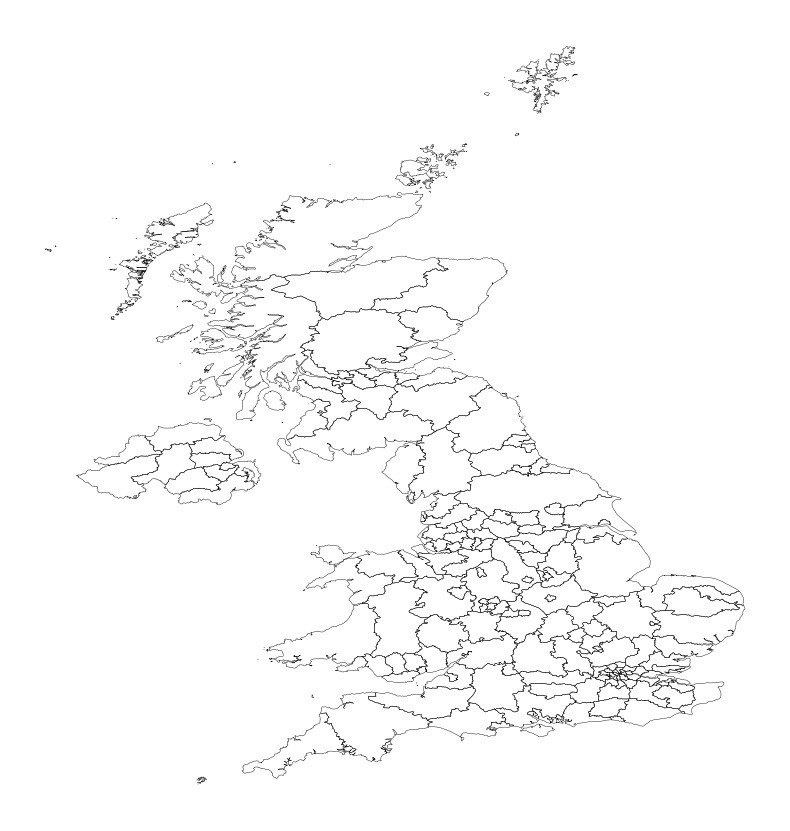

In [27]:
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=(8, 10))

regions = regions[regions['CNTR_CODE'] == 'UK']
regions.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.3
)

ax.set_axis_off()
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

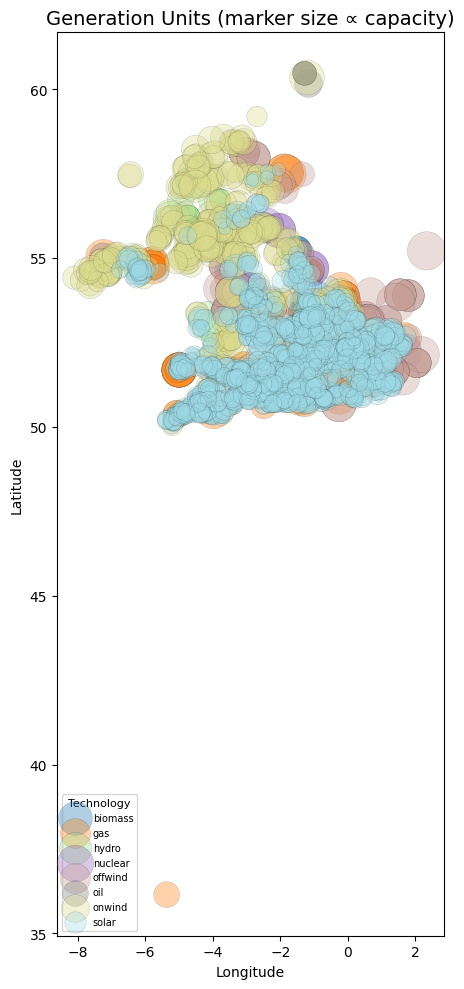

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# gdf_units columns (from your screenshot):
# ['UnitID','Bus_name','x','y','capacity_mw','Cost','Carbon','Type',
#  'geometry','norm_capacity','radius','marker_size']

fig, ax = plt.subplots(figsize=(8, 10))

# unique technologies and give each one a color
techs = sorted(gdf_units["Type"].unique())
colors = plt.cm.tab20(np.linspace(0, 1, len(techs)))
color_map = dict(zip(techs, colors))

for tech in techs:
    sub = gdf_units[gdf_units["Type"] == tech]
    ax.scatter(
        sub["x"],                  # longitude
        sub["y"],                  # latitude
        s=sub["marker_size"],      # size already ∝ capacity
        color=color_map[tech],     # color per technology
        alpha=0.35,                # transparency for overlap
        edgecolor="black",
        linewidth=0.2,
        label=tech,
    )

ax.set_title("Generation Units (marker size ∝ capacity)", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title="Technology", fontsize=7, title_fontsize=8, loc="lower left")

ax.set_aspect("equal", adjustable="box")  # keeps UK shape reasonable

plt.tight_layout()
plt.show()


## Capacity distribution figure (folium)

In [7]:
import folium
import geopandas as gpd

gen_map = folium.Map(
    max_bounds=True, 
    min_lat=-70,
    max_lat=70,
    min_lon=-150,
    max_lon=150,
    control_scale=False, # Show a scale on the bottom of the map
    zoom_control=False, # shows zoom buttons by default
    tiles="CartoDB positron")    


In [8]:
df_units = gdf_units.copy()
geometry_gens = gpd.points_from_xy(df_units.x, df_units.y)
geo_units_df = gpd.GeoDataFrame(df_units, geometry=geometry_gens, crs="EPSG:4326")
geo_units_df

,UnitID,Bus name,x,y,capacity_mw,Cost,Carbon,Type,geometry
0,1,way/160580052-400,-0.996389,53.735800,2580.0,230.224337,53.1,biomass,POINT (-0.99639 53.7358)
1,2,way/91010711-400,0.492400,51.293100,43.0,230.601565,53.1,biomass,POINT (0.4924 51.2931)
2,3,way/292471784-400,-2.668700,51.532900,34.0,230.703112,53.1,biomass,POINT (-2.6687 51.5329)
3,4,way/101312018-275,-1.400700,53.420400,30.0,230.767801,53.1,biomass,POINT (-1.4007 53.4204)
4,5,GB32-400,-0.509200,53.542300,40.0,230.630336,53.1,biomass,POINT (-0.5092 53.5423)
...,...,...,...,...,...,...,...,...,...
1936,1937,way/26678829-400,-3.531310,50.712540,21.0,93.549502,384.0,gas,POINT (-3.53131 50.71254)
1937,1938,relation/13110369-400,-0.811836,53.362719,450.0,84.103442,384.0,gas,POINT (-0.81184 53.36272)
1938,1939,relation/13110369-400,-0.811836,53.362719,460.0,84.093390,384.0,gas,POINT (-0.81184 53.36272)
1939,1940,relation/13110369-400,-0.811836,53.362719,450.0,84.103442,384.0,gas,POINT (-0.81184 53.36272)


In [9]:
grp = geo_units_df.groupby('Type')['capacity_mw']
mins = grp.transform('min')
maxs = grp.transform('max')
ranges = maxs - mins

df_units['norm_capacity'] = np.where(
    ranges == 0,
    1.0,
    (df_units['capacity_mw'] - mins) / ranges
)

min_radius = 5
max_radius = 10

def scale_radius(norm_val):
    return min_radius + norm_val * (max_radius - min_radius)

df_units['radius'] = df_units['norm_capacity'].apply(scale_radius)

type_colors = {
    'biomass':  '#8dd3c7',
    'solar':    '#fed976',
    'onwind':   '#80b1d3',
    'offwind':  '#1f78b4',
    'nuclear':  '#984ea3',
    'hydro':    '#4daf4a',
    'coal':     '#666666',
    'gas':      '#fb8072',
    'oil':      '#ff7f00',
}

fallback_color = '#999999'

# load GB borders
url = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip"
world = gpd.read_file(url)
uk = world[world["NAME"] == "United Kingdom"]
bounds = uk.total_bounds  # [minx, miny, maxx, maxy]

map_GB = folium.Map(location=[54.5, -3], zoom_start=6, tiles='cartodbpositron')

map_GB.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])

layers = {t: folium.FeatureGroup(name=t, show=True).add_to(map_GB) for t in type_colors.keys()}
layers['other'] = folium.FeatureGroup(name='other', show=False).add_to(map_GB)

def radius_from_capacity(cap):
    cap = max(float(cap), 1.0)
    # log10(1)=0 → log10(2580)=3.41
    norm = np.log10(cap) / np.log10(2580)
    min_r = 12
    max_r = 42
    return min_r + norm * (max_r - min_r)

for _, row in df_units.iterrows():
    carrier = str(row.get('Type', ''))
    color = type_colors.get(carrier, fallback_color)
    layer_key = carrier if carrier in type_colors else 'other'

    popup_html = f"""
    <b>UnitID:</b> {row.get('UnitID', '')}<br>
    <b>Type:</b> {carrier}<br>
    <b>x:</b> {row.get('x', '')}<br>
    <b>y:</b> {row.get('y', '')}<br>
    <b>Capacity:</b> {row.get('capacity_mw', '')}
    """
    folium.CircleMarker(
        location=[row['y'], row['x']],
        radius=radius_from_capacity(row.get('capacity_mw', None)),
        color=color,
        fill=True,
        fill_opacity=0.75,
        weight=1,
        popup=folium.Popup(popup_html, max_width=260)
    ).add_to(layers[layer_key])


legend_html = """
<div style="
     position: fixed; 
     bottom: 30px; left: 30px; z-index: 9999; 
     background: white; padding: 10px 12px; border: 1px solid #ccc; 
     border-radius: 6px; font-size: 13px;">
<b>Unit Type</b><br>
{}
</div>
""".format("<br>".join(
    [f'<span style="display:inline-block;width:10px;height:10px;background:{c};margin-right:6px;border:1px solid #888;"></span>{t}'
     for t, c in type_colors.items()] + 
    [f'<span style="display:inline-block;width:10px;height:10px;background:{fallback_color};margin-right:6px;border:1px solid #888;"></span>other']
))
map_GB.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl(collapsed=False).add_to(map_GB)

output_path = 'interactive_map.html'
map_GB.save(output_path)
print(f"Interactive map saved to {output_path}")


Interactive map saved to interactive_map.html


### Save to png

In [10]:
import os
import time
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

# ===== 输入文件 =====
html_path = os.path.abspath("interactive_map.html")
png_path  = "gb_units_map.png"

# ===== 参数 =====
BASE_WIDTH  = 1800
BASE_HEIGHT = 1800
DEVICE_SCALE = 2
PAGE_ZOOM    = 2  # 这里只控制分辨率倍数

# ===== 修正窗口尺寸（关键！避免裁切） =====
WINDOW_WIDTH  = int(BASE_WIDTH  * PAGE_ZOOM)
WINDOW_HEIGHT = int(BASE_HEIGHT * PAGE_ZOOM)

# ===== Chrome 配置 =====
chrome_options = Options()
chrome_options.add_argument("--headless=new")
chrome_options.add_argument(f"--window-size={WINDOW_WIDTH},{WINDOW_HEIGHT}")
chrome_options.add_argument(f"--force-device-scale-factor={DEVICE_SCALE}")
chrome_options.add_argument("--hide-scrollbars")

service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=chrome_options)

try:
    driver.get("file://" + html_path)

    # 🔥 调整中心 + 放大英国
    driver.execute_script("""
    (function(){
      for (var key in window) {
          var m = window[key];
          if (m && m.setView && m.getCenter && m.getZoom) {
              var c = m.getCenter();
              var deltaLat = 1.0;    // 往南一点
              var deltaLng = -1.0;    // 往东一点
              var newZoom  = m.getZoom() + 1.0;  // 放大一点（可改为 0.5 / 1.0）
              m.setView([c.lat - deltaLat, c.lng + deltaLng], newZoom);
              break;
          }
      }
    })();
    """)

    # 隐藏控件
    driver.execute_script("""
    (function(){
      let els = document.querySelectorAll(
        '.leaflet-control, .leaflet-bottom.leaflet-right, .leaflet-control-attribution'
      );
      els.forEach(e => e.style.display='none');
    })();
    """)

    time.sleep(2.0)
    driver.save_screenshot(png_path)
    print("✅ PNG saved:", png_path)

finally:
    driver.quit()


✅ PNG saved: gb_units_map.png


In [11]:
from PIL import Image

png_path = "gb_units_map.png"
cropped_path = "gb_units_map_cropped.png"

img = Image.open(png_path)
w, h = img.size

target_ratio = 1350 / 1800
new_w = int(w * target_ratio)

left = (w - new_w) // 2
right = left + new_w

# 居中裁剪（上下不动，只裁左右）
img_cropped = img.crop((left, 0, right, h))
img_cropped.save(cropped_path)

print("saved:", cropped_path)


saved: gb_units_map_cropped.png


## Bars

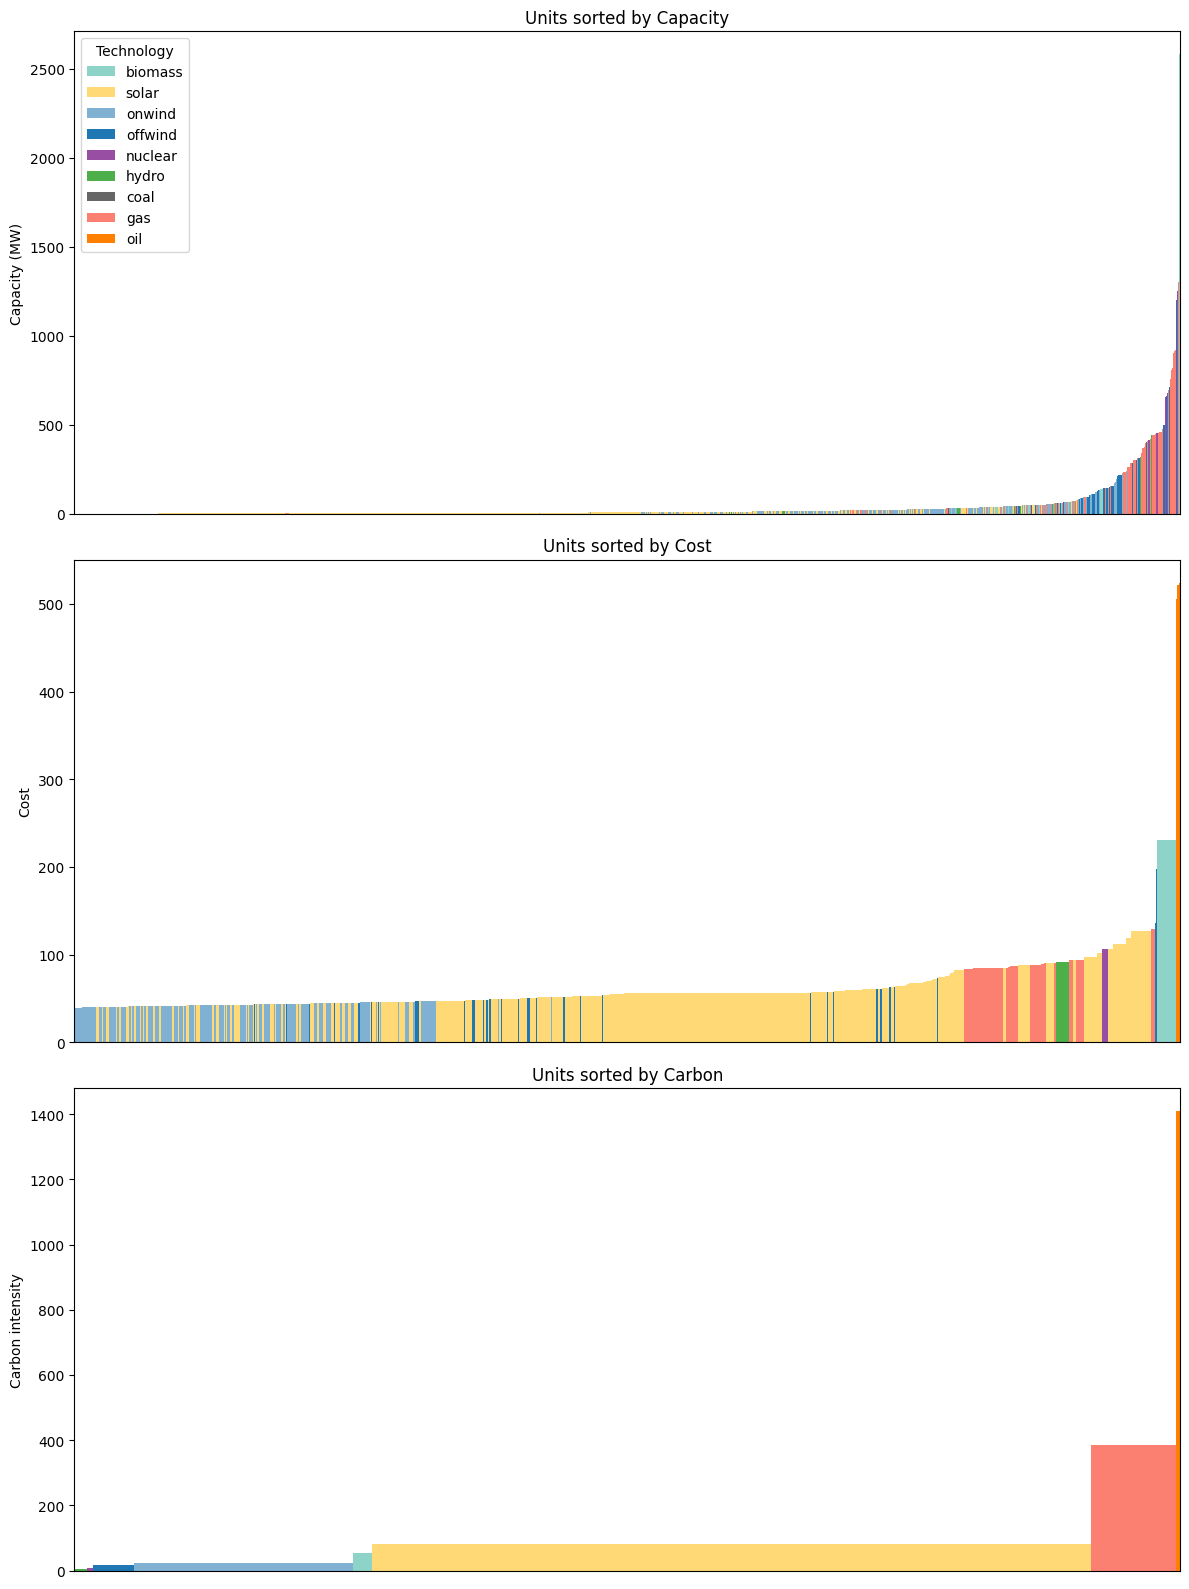

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ---- color mapping (same as your folium map) ----
type_colors = {
    'biomass':  '#8dd3c7',
    'solar':    '#fed976',
    'onwind':   '#80b1d3',
    'offwind':  '#1f78b4',
    'nuclear':  '#984ea3',
    'hydro':    '#4daf4a',
    'coal':     '#666666',
    'gas':      '#fb8072',
    'oil':      '#ff7f00',
}

# ---- metrics to plot: (column_name, y label, title) ----
metrics = [
    ('capacity_mw', 'Capacity (MW)',    'Units sorted by Capacity'),
    ('Cost',        'Cost',             'Units sorted by Cost'),
    ('Carbon',      'Carbon intensity', 'Units sorted by Carbon'),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 16), sharex=False)

for ax, (col, ylabel, title) in zip(axes, metrics):
    # 按当前指标排序
    df_sorted = df_units.sort_values(col, ascending=True)

    x = np.arange(len(df_sorted))
    y = df_sorted[col].values

    # 类型映射到颜色
    colors = df_sorted['Type'].map(type_colors).fillna('#999999')

    # bar 之间无空隙：width=1.0 + xlim 收紧
    ax.bar(x, y, color=colors, width=1.0)
    ax.set_xlim(-0.5, len(df_sorted) - 0.5)

    ax.set_ylabel(ylabel)
    ax.set_title(title)

    # unit 太多的话 x 轴标签会糊掉，这里先隐藏
    ax.set_xticks([])

# ---- legend from type_colors ----
legend_handles = [
    Patch(facecolor=c, edgecolor='none', label=t)
    for t, c in type_colors.items()
]
axes[0].legend(handles=legend_handles, title='Technology', loc='upper left')

plt.tight_layout()
plt.show()


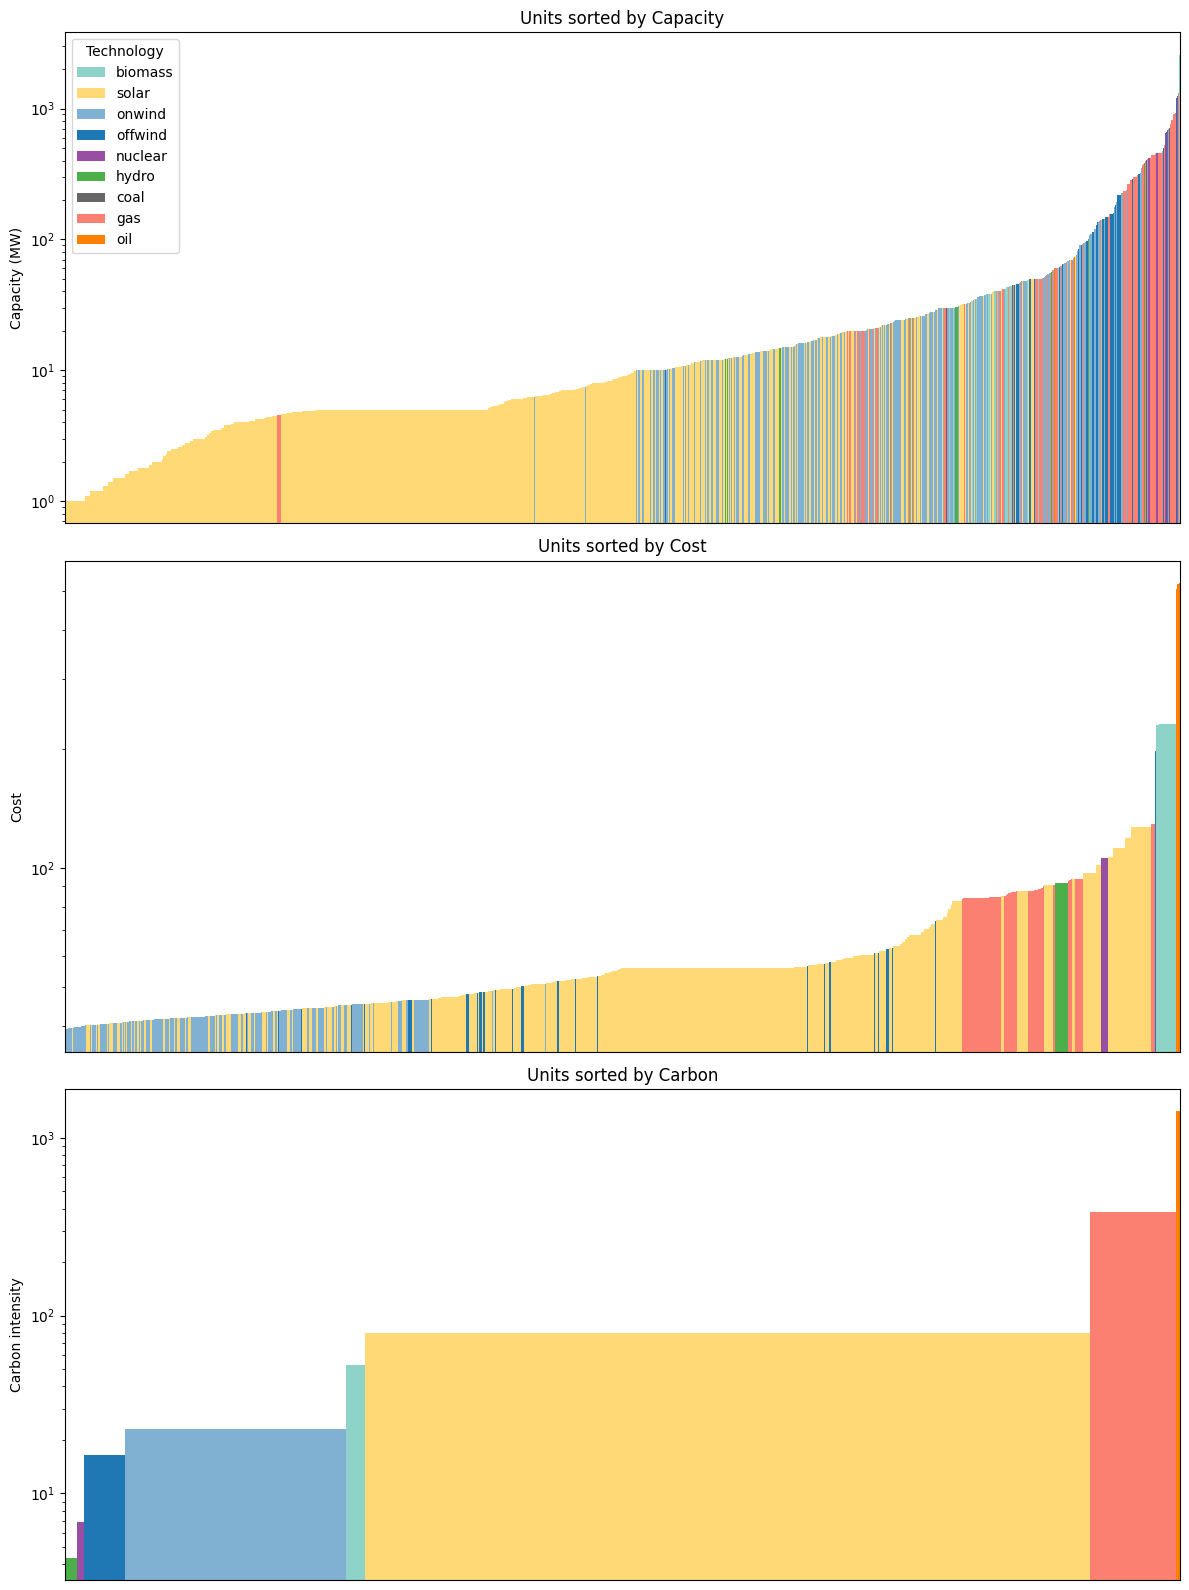

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ---- color mapping (same as your folium map) ----
type_colors = {
    'biomass':  '#8dd3c7',
    'solar':    '#fed976',
    'onwind':   '#80b1d3',
    'offwind':  '#1f78b4',
    'nuclear':  '#984ea3',
    'hydro':    '#4daf4a',
    'coal':     '#666666',
    'gas':      '#fb8072',
    'oil':      '#ff7f00',
}

# ---- metrics to plot: (column_name, y label, title) ----
metrics = [
    ('capacity_mw', 'Capacity (MW)',    'Units sorted by Capacity'),
    ('Cost',        'Cost',             'Units sorted by Cost'),
    ('Carbon',      'Carbon intensity', 'Units sorted by Carbon'),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 16), sharex=False)

for ax, (col, ylabel, title) in zip(axes, metrics):
    df_sorted = df_units.sort_values(col, ascending=True)

    x = np.arange(len(df_sorted))
    y = df_sorted[col].values

    colors = df_sorted['Type'].map(type_colors).fillna('#999999')

    # bar 之间无空隙
    ax.bar(x, y, color=colors, width=1.0)
    ax.set_xlim(-0.5, len(df_sorted) - 0.5)

    ax.set_ylabel(ylabel)
    ax.set_title(title)

    # ⭐ 设置对数坐标
    ax.set_yscale('log')

    # 隐藏 x 轴标签
    ax.set_xticks([])

# ---- legend ----
legend_handles = [
    Patch(facecolor=c, edgecolor='none', label=t)
    for t, c in type_colors.items()
]
axes[0].legend(handles=legend_handles, title='Technology', loc='upper left')

plt.tight_layout()
plt.show()
